In [ ]:
import numpy as np #helps us in numerical operations
import pandas as pd # helps us to work with tables
import matplotlib.pyplot as plt #helps us to plot some graphs, simple plots


# Scikit-learn tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

from IPython.display import display

# Display settings for better table viewing
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:


## Load and Read credit_applicants.csv file

df_credit_applicants = pd.read_csv("data/credit_applicants.csv")

# =========================
# 2. Basic inspection (No. of rows x columns)
# =========================
print("Credit applicant data size: ", df_credit_applicants.shape)



Credit applicant data size:  (400, 10)


In [ ]:
## Get summary stats of the df

df_credit_applicants.describe()

,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,default
count,400.000000,400.00000,400.000000,400.00000,400.000000,400.000000,320.00000,400.000000
mean,40.895000,80401.33250,1.937500,0.50630,62311.332500,1.217500,601.80000,0.202500
std,11.525235,39565.41542,1.429581,0.26983,35032.772817,1.090029,171.93156,0.402366
min,21.000000,15404.00000,0.000000,0.05000,2207.000000,0.000000,302.00000,0.000000
25%,31.000000,42630.25000,1.000000,0.26000,32427.750000,0.000000,439.75000,0.000000
50%,42.000000,80749.00000,2.000000,0.51500,62404.500000,1.000000,610.50000,0.000000
75%,51.000000,116683.25000,3.000000,0.74000,94188.750000,2.000000,751.00000,0.000000
max,59.000000,149668.00000,4.000000,0.95000,119867.000000,5.000000,898.00000,1.000000


In [ ]:
df_credit_applicants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   applicant_id              400 non-null    object 
 1   age                       400 non-null    int64  
 2   monthly_income_inr        400 non-null    int64  
 3   existing_loans_count      400 non-null    int64  
 4   credit_utilization_ratio  400 non-null    float64
 5   upi_monthly_inflow_inr    400 non-null    int64  
 6   bounced_payments_count    400 non-null    int64  
 7   credit_bureau_score       320 non-null    float64
 8   employment_type           400 non-null    object 
 9   default                   400 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 31.4+ KB


In [ ]:

##### Display few txns head()

df_credit_applicants.head()


,applicant_id,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type,default
0,APP1000,59,41646,4,0.80,17398,2,NaN,salaried,1
1,APP1001,49,119185,0,0.08,58503,3,380.0,salaried,0
2,APP1002,35,38049,0,0.59,8638,1,788.0,salaried,1
3,APP1003,28,113116,0,0.26,8570,2,387.0,salaried,0
4,APP1004,41,112379,2,0.16,70785,3,493.0,salaried,0


In [ ]:

## 1. Report the exact measured default rate
## and the exact percentage of missing credit_bureau_score values.


## Calc the default rate:
default_rate = (df_credit_applicants["default"].sum()/len(df_credit_applicants))*100
print(f"Default rate: {default_rate:.2f}%")


#Calculate rows with credit_bureau_score blank or null/ total no. of rows in %
missing_credit_bureau_score = (df_credit_applicants["credit_bureau_score"].isnull().sum()/len(df_credit_applicants))*100
print(f"Missing credit bureau score: {missing_credit_bureau_score:.2f}%")


Default rate: 20.25%
Missing credit bureau score: 20.00%


In [ ]:
## Add column is_thin_file to df_credit_applicants, where it is TRUE if column credit_bureau_score is null or blank
df_credit_applicants["is_thin_file"] = df_credit_applicants["credit_bureau_score"].isnull()




df_credit_applicants.head(15)

,applicant_id,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type,default,is_thin_file
0,APP1000,59,41646,4,0.80,17398,2,NaN,salaried,1,True
1,APP1001,49,119185,0,0.08,58503,3,380.0,salaried,0,False
2,APP1002,35,38049,0,0.59,8638,1,788.0,salaried,1,False
3,APP1003,28,113116,0,0.26,8570,2,387.0,salaried,0,False
4,APP1004,41,112379,2,0.16,70785,3,493.0,salaried,0,False
5,APP1005,59,83385,2,0.12,11110,0,403.0,self_employed,0,False
6,APP1006,39,141131,0,0.68,107899,1,395.0,gig,0,False
7,APP1007,43,38289,4,0.36,81141,1,722.0,salaried,0,False
8,APP1008,31,125226,3,0.70,14115,3,NaN,gig,1,True
9,APP1009,31,115793,3,0.11,41062,3,NaN,salaried,0,True


In [ ]:
## Split dataset into train/test
## (75/25, stratified on default, justify the stratification choice;
## use random_state=42 for the split so results are reproducible), then, in this order:



standard_feature_names = ["applicant_id","age","monthly_income_inr",
                          "existing_loans_count","credit_utilization_ratio",
                          "upi_monthly_inflow_inr","bounced_payments_count",
                          "credit_bureau_score","employment_type","is_thin_file"]
target_feature_name = "default"

X_data = df_credit_applicants[standard_feature_names].copy()
Y_data = df_credit_applicants[target_feature_name].copy()

display(X_data.head())
display(Y_data.head())

print("X_data size: ", X_data.shape)
print("Y_data size: ", Y_data.shape)



,applicant_id,age,monthly_income_inr,existing_loans_count,credit_utilization_ratio,upi_monthly_inflow_inr,bounced_payments_count,credit_bureau_score,employment_type,is_thin_file
0,APP1000,59,41646,4,0.80,17398,2,NaN,salaried,True
1,APP1001,49,119185,0,0.08,58503,3,380.0,salaried,False
2,APP1002,35,38049,0,0.59,8638,1,788.0,salaried,False
3,APP1003,28,113116,0,0.26,8570,2,387.0,salaried,False
4,APP1004,41,112379,2,0.16,70785,3,493.0,salaried,False


,default
0,1
1,0
2,1
3,0
4,0


X_data size:  (400, 10)
Y_data size:  (400,)


In [ ]:

## Set 75% data for training, and 25% for testing/validation:

X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    Y_data,
    test_size=0.25,
    random_state=42,
    stratify=Y_data
)

In [ ]:

## Calculate  the median of the non-missing credit_bureau_score values using only the training split
median_credit_bureau_score = X_train["credit_bureau_score"].median()
print(f"Median credit bureau score: {median_credit_bureau_score:.0f}")


X_train_replace_crbureau =    X_train.copy()
X_test_replace_crbureau = X_test.copy()


## We choose Median of credit_bureau_score, to replace missing credit_bureau_score fields, as median is not affected by outliers.
## We do not use information (median) from the test data during the training phase, as test data is supposed to be unseen data for your model. Your model cannot be trained on the unseen dat, it will be information leak into the training model, which will produce incorrect training for your model.
## Also, for those applicants who do not have credit_bureau_score, we can analyze them using alternate data, hence we do not drop those rows


## In X_train_replace_crbureau, if the column credit_bureau_score is empty or null, replace it with median_credit_bureau_score
X_train_replace_crbureau = X_train_replace_crbureau.fillna(median_credit_bureau_score)


display(X_train_replace_crbureau["credit_bureau_score"])



## In X_test_replace_crbureau, if the column credit_bureau_score is empty or null, replace it with median_credit_bureau_score
X_test_replace_crbureau = X_test_replace_crbureau.fillna(median_credit_bureau_score)

display(X_test_replace_crbureau["credit_bureau_score"])



## Find all rows where X_train_replace_crbureau["credit_bureau_score"] this column is blank or null
#rows_train_with_missing_credit_bureau_score = X_train_replace_crbureau[X_train_replace_crbureau["credit_bureau_score"].isnull()]
#print("Rows with empty credit_bureau_score in X_train: ", rows_train_with_missing_credit_bureau_score)  ## returns 0 rows


## Find all rows where X_test_replace_crbureau["credit_bureau_score"] this column is blank or null
#rows_test_with_missing_credit_bureau_score = X_test_replace_crbureau[X_test_replace_crbureau["credit_bureau_score"].isnull()]
#print("Rows with empty credit_bureau_score in X_test: ", rows_test_with_missing_credit_bureau_score)  ## returns 0 rows







Median credit bureau score: 612


,credit_bureau_score
84,582.0
10,612.0
384,624.0
359,808.0
11,677.0
...,...
51,612.0
335,546.0
275,872.0
29,375.0


,credit_bureau_score
68,612.0
265,391.0
267,362.0
138,507.0
125,869.0
...,...
270,484.0
292,495.0
117,868.0
119,517.0


### Next part: Using preprocesser for:
  

*   OneHot coding for category fields, and
*   Convert Num fields using StandarScaler

## This comes from: sklearn.preprocessing import OneHotEncoder, StandardScaler


In [ ]:
categorical_cols = ["employment_type"]

numeric_cols = [
    col for col in standard_feature_names
    if col not in categorical_cols and col != "applicant_id"
]

def make_preprocessor():
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", onehot, categorical_cols),
            ("num", StandardScaler(), numeric_cols)
        ]
    )

    return preprocessor

In [ ]:

# 1. Extract and store applicant IDs separately
applicant_ids_train = X_train_replace_crbureau['applicant_id']
applicant_ids_test = X_test_replace_crbureau['applicant_id']

# 2. Drop applicant_id from feature sets before passing to preprocessor
X_train_features = X_train_replace_crbureau.drop(columns=['applicant_id'])
X_test_features = X_test_replace_crbureau.drop(columns=['applicant_id'])


In [ ]:



preprocessor = make_preprocessor()

X_train_prepared = preprocessor.fit_transform(X_train_features)
X_test_prepared = preprocessor.transform(X_test_features)

print("Prepared training shape:", X_train_prepared.shape)
print("Prepared testing shape:", X_test_prepared.shape)



Prepared training shape: (300, 11)
Prepared testing shape: (100, 11)


In [ ]:

## Convert the prepared X train and X test data to dataframe and display it

feature_names = preprocessor.get_feature_names_out()
X_train_prepared_df = pd.DataFrame(X_train_prepared, columns=feature_names)
#X_train_prepared_df = pd.DataFrame(X_train_prepared)
display(X_train_prepared_df.head())

,cat__employment_type_gig,cat__employment_type_salaried,cat__employment_type_self_employed,num__age,num__monthly_income_inr,num__existing_loans_count,num__credit_utilization_ratio,num__upi_monthly_inflow_inr,num__bounced_payments_count,num__credit_bureau_score,num__is_thin_file
0,0.0,0.0,1.0,-1.145762,0.952812,0.053277,0.149735,0.995851,-0.227884,-0.148387,-0.510396
1,0.0,1.0,0.0,0.270945,-1.385434,-0.641639,-0.587877,-1.151228,-0.227884,0.048994,1.959263
2,0.0,0.0,1.0,0.713666,-1.586508,-0.641639,-1.436132,0.076032,-1.127427,0.127947,-0.510396
3,1.0,0.0,0.0,-0.171776,0.287041,0.053277,1.588080,-0.656830,-0.227884,1.338550,-0.510396
4,0.0,1.0,0.0,1.333476,-0.576811,1.443108,0.186616,1.211575,-0.227884,0.476653,-0.510396


## We can display Evaluation metrics, Default rates, etc in scale from 0 to 1 in decimals or as %

## With the X_train_prepared you prepeared , use this training data to train a LogisticRegression model:
log_reg_without_balance = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_without_balance.fit(X_train_prepared, y_train)

In [ ]:

log_reg_without_balance = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg_without_balance.fit(X_train_prepared, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Use this funciton - evaluate_model to compute Logistic Regression model evalution metrics:


*   Accuracy
*   Precision
*   Recall
*   F1 Score
*   ROC
*   AUC







In [ ]:

#========================
#  Evaluate a model to calculate Classification model Evaluation metrics like Precision, Recall, F1, etc
#========================



evaluation_results = []

def evaluate_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_proba)
    else:
        y_proba = None
        roc_auc = np.nan

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred)
    rec = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred, target_names=["No Default", "Default"]))

    ConfusionMatrixDisplay.from_predictions(
        y_test_data,
        y_pred,
        display_labels=["No Default", "Default"],
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test_data, y_proba)
        plt.title(f"ROC Curve - {model_name}")
        plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    }

Logistic Regression Without Balancing
Accuracy : 0.76
Precision: 0.3889
Recall   : 0.35
F1-score : 0.3684
ROC-AUC  : 0.7188

Classification Report:
              precision    recall  f1-score   support

  No Default       0.84      0.86      0.85        80
     Default       0.39      0.35      0.37        20

    accuracy                           0.76       100
   macro avg       0.62      0.61      0.61       100
weighted avg       0.75      0.76      0.76       100



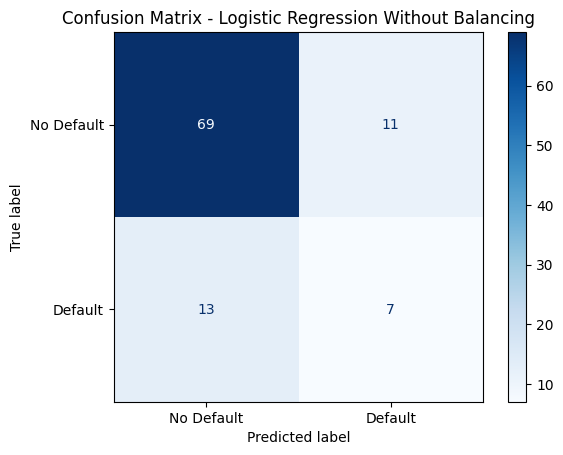

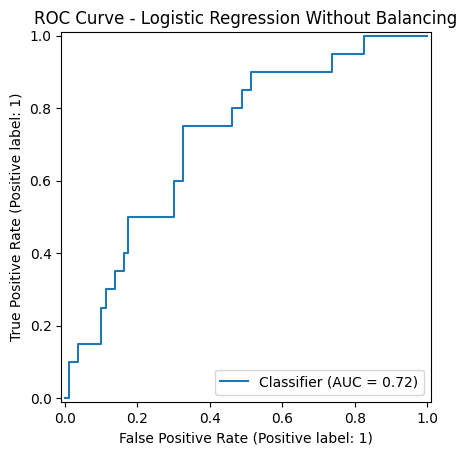

In [ ]:

result_logis = evaluate_model(
    "Logistic Regression Without Balancing",
    log_reg_without_balance,
    X_test_prepared,
    y_test
)

evaluation_results.append(result_logis)

## Now with the X_train_prepared you prepeared , use this training data, fit/train a DecisionTree Classifier model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Fit the model to the prepared training data
decision_tree_model.fit(X_train_prepared, y_train)

DecisionTreeClassifier(random_state=42)

Decision Tree Classifier
Accuracy : 0.65
Precision: 0.2222
Recall   : 0.3
F1-score : 0.2553
ROC-AUC  : 0.5188

Classification Report:
              precision    recall  f1-score   support

  No Default       0.81      0.74      0.77        80
     Default       0.22      0.30      0.26        20

    accuracy                           0.65       100
   macro avg       0.52      0.52      0.51       100
weighted avg       0.69      0.65      0.67       100



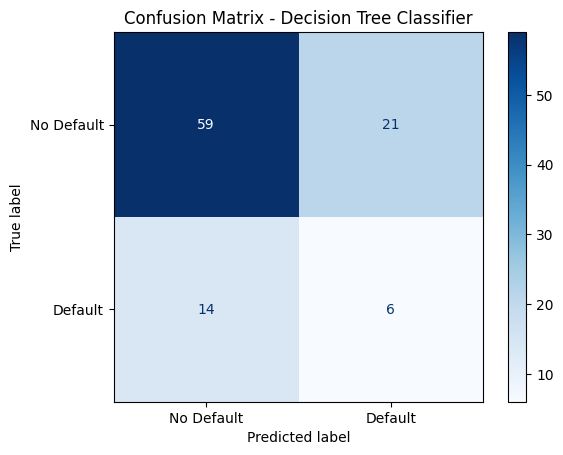

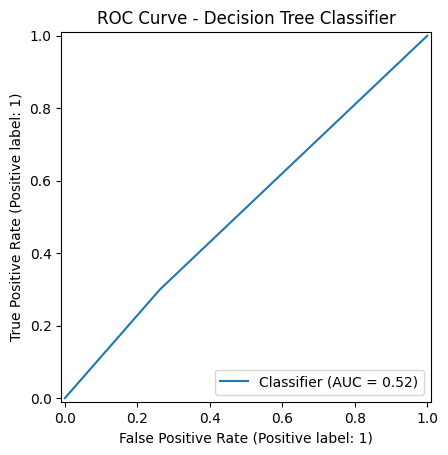

In [ ]:
# Evaluate the Decision Tree Classifier model
result_dt = evaluate_model(
    "Decision Tree Classifier",
    decision_tree_model,
    X_test_prepared,
    y_test
)

evaluation_results.append(result_dt)

## Compare the Evaluation metric results of Logistic Regression and Decision Tree Classifier:

In [ ]:
comparison_df = pd.DataFrame(evaluation_results)
display(comparison_df.set_index('Model'))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression Without Balancing,0.76,0.388889,0.35,0.368421,0.71875
Decision Tree Classifier,0.65,0.222222,0.30,0.255319,0.51875


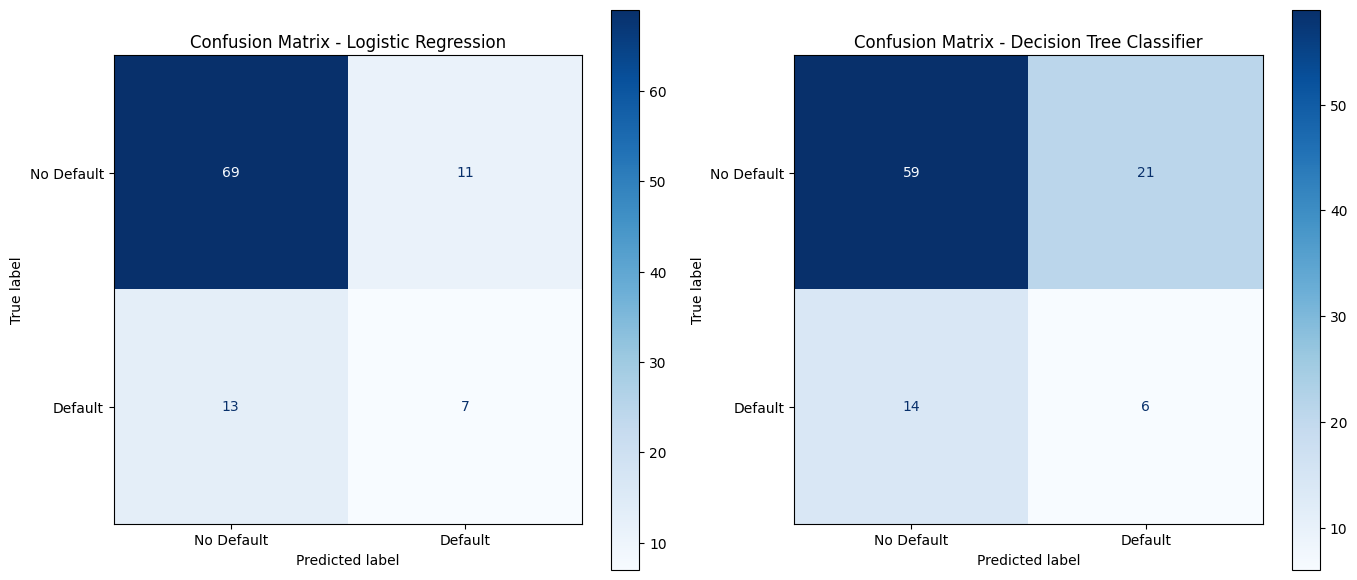

In [ ]:
import matplotlib.pyplot as plt

# Make predictions for both models
y_pred_log_reg = log_reg_without_balance.predict(X_test_prepared)
y_pred_dt = decision_tree_model.predict(X_test_prepared)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Confusion Matrix for Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log_reg,
    display_labels=["No Default", "Default"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix - Logistic Regression')

# Plot Confusion Matrix for Decision Tree Classifier
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=["No Default", "Default"],
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix - Decision Tree Classifier')

plt.tight_layout()
plt.show()

## Using the logistic regression's predicted probabilities, bucket applicants into at least 4 risk tiers (e.g., quartiles of predicted default probability) and assign each tier an illustrative interest-rate range in percent

In [ ]:
y_pred_proba_log_reg = log_reg_without_balance.predict_proba(X_test_prepared)[:, 1]

# Create a DataFrame to store applicant_id, predicted probabilities, and later, risk tiers and interest rates
prob_applic_df = pd.DataFrame({
    'applicant_id': applicant_ids_test,
    'predicted_default_proba': y_pred_proba_log_reg
})

# Sort by predicted probability in ascending order
prob_applic_df = prob_applic_df.sort_values(by='predicted_default_proba').reset_index(drop=True)

# Create 4 risk tiers (quartiles)
prob_applic_df['default_buckets'] = pd.qcut(
    prob_applic_df['predicted_default_proba'],
    q=4,
    labels=['Tier 1 (Lowest Risk)', 'Tier 2', 'Tier 3', 'Tier 4 (Highest Risk)']
)

# Assign differential interest rates based on tiers
interest_rate_map = {
    'Tier 1 (Lowest Risk)': '1%',
    'Tier 2': '2%',
    'Tier 3': '4%',
    'Tier 4 (Highest Risk)': '8%'
}
prob_applic_df['differential_interest_rate'] = prob_applic_df['default_buckets'].map(interest_rate_map)

display(prob_applic_df.head(10))
display(prob_applic_df.tail(10))
# =========================
# Export the logistic regression probabilities with the tier based interest
# =========================

prob_applic_df.to_csv('prob_applic_df.csv', index=False)



,applicant_id,predicted_default_proba,default_buckets,differential_interest_rate
0,APP1068,0.004897,Tier 1 (Lowest Risk),1%
1,APP1192,0.005309,Tier 1 (Lowest Risk),1%
2,APP1365,0.005821,Tier 1 (Lowest Risk),1%
3,APP1223,0.006273,Tier 1 (Lowest Risk),1%
4,APP1086,0.006499,Tier 1 (Lowest Risk),1%
5,APP1186,0.007173,Tier 1 (Lowest Risk),1%
6,APP1100,0.012348,Tier 1 (Lowest Risk),1%
7,APP1208,0.014781,Tier 1 (Lowest Risk),1%
8,APP1316,0.017259,Tier 1 (Lowest Risk),1%
9,APP1153,0.018744,Tier 1 (Lowest Risk),1%


,applicant_id,predicted_default_proba,default_buckets,differential_interest_rate
90,APP1045,0.585647,Tier 4 (Highest Risk),8%
91,APP1333,0.614522,Tier 4 (Highest Risk),8%
92,APP1238,0.685601,Tier 4 (Highest Risk),8%
93,APP1201,0.704846,Tier 4 (Highest Risk),8%
94,APP1091,0.710000,Tier 4 (Highest Risk),8%
95,APP1380,0.724900,Tier 4 (Highest Risk),8%
96,APP1398,0.805997,Tier 4 (Highest Risk),8%
97,APP1214,0.833977,Tier 4 (Highest Risk),8%
98,APP1123,0.884538,Tier 4 (Highest Risk),8%
99,APP1265,0.946459,Tier 4 (Highest Risk),8%


/tmp/ipykernel_714/1996255192.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=prob_applic_df, x='default_buckets', order=['Tier 1 (Lowest Risk)', 'Tier 2', 'Tier 3', 'Tier 4 (Highest Risk)'], palette='viridis')


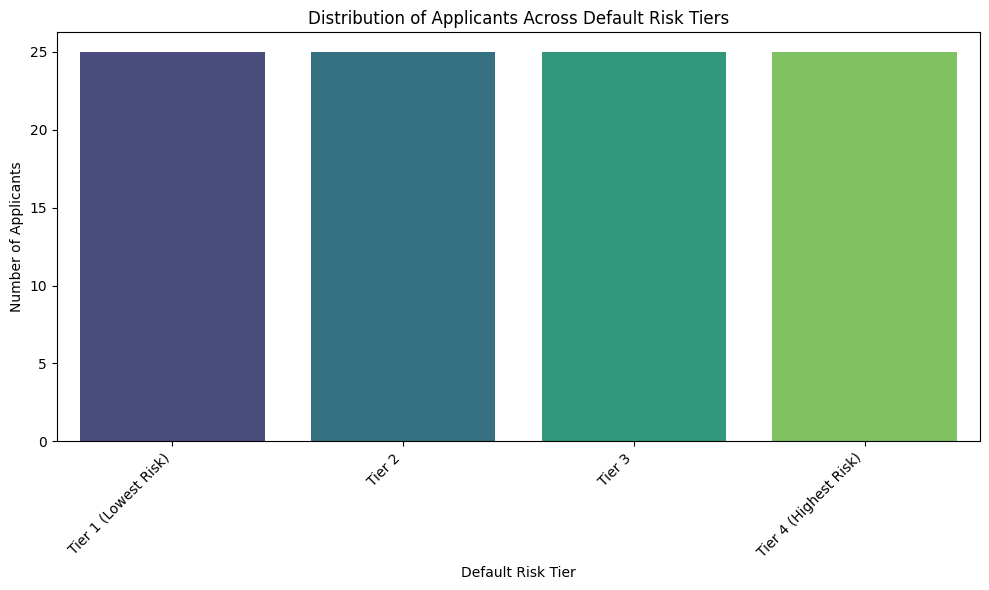


Number of applicants in each default risk tier:


,count
default_buckets,
Tier 1 (Lowest Risk),25
Tier 2,25
Tier 3,25
Tier 4 (Highest Risk),25


In [ ]:
import seaborn as sns

# Visualize the distribution of applicants across default buckets
plt.figure(figsize=(10, 6))
sns.countplot(data=prob_applic_df, x='default_buckets', order=['Tier 1 (Lowest Risk)', 'Tier 2', 'Tier 3', 'Tier 4 (Highest Risk)'], palette='viridis')
plt.title('Distribution of Applicants Across Default Risk Tiers')
plt.xlabel('Default Risk Tier')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the count of applicants in each bucket as a table
print("\nNumber of applicants in each default risk tier:")
display(prob_applic_df['default_buckets'].value_counts().sort_index())

## Find the Actual Observed Default Rate within Each tier

In [ ]:
## Calculate the actual observed Default rate within Each tier bucket
y_test_df = pd.DataFrame({
    'applicant_id': applicant_ids_test,
    'actual_default': y_test
})


## Create a DF - actual_vs_predicted_test by Joining y_test_df, prob_applic_df on applicant_id
actual_vs_predicted_test_df = pd.merge(y_test_df, prob_applic_df, on='applicant_id', how='inner')

#display(actual_vs_predicted_test_df.head(10))
#display(actual_vs_predicted_test_df.tail(10))

# For each default_buckets category, calculate the actual observed default rate

observed_default_rates = actual_vs_predicted_test_df.groupby('default_buckets')['actual_default'].mean()

print("\nActual observed default rate within each tier:")

# Sort by the order of buckets to ensure monotonicity check is clear
ordered_tiers = ['Tier 1 (Lowest Risk)', 'Tier 2', 'Tier 3', 'Tier 4 (Highest Risk)']
observed_default_rates = observed_default_rates[ordered_tiers]

#Display the observed default rates by buckets:
display(observed_default_rates)


Actual observed default rate within each tier:


/tmp/ipykernel_714/703849111.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observed_default_rates = actual_vs_predicted_test_df.groupby('default_buckets')['actual_default'].mean()


,actual_default
default_buckets,
Tier 1 (Lowest Risk),0.08
Tier 2,0.12
Tier 3,0.20
Tier 4 (Highest Risk),0.40
